Tools with arxiv and wikipedia

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

In [3]:
arxiv_api_wrapper=ArxivAPIWrapper(top_k_results=5,load_max_docs=100)
arxiv_query=ArxivQueryRun(api_wrapper=arxiv_api_wrapper)

In [5]:
wiki_api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max=200)
wiki_query=WikipediaQueryRun(api_wrapper=wiki_api_wrapper)

In [8]:
arxiv_query.invoke("tell about MCP")

'Published: 2025-08-20\nTitle: MCP-Universe: Benchmarking Large Language Models with Real-World Model Context Protocol Servers\nAuthors: Ziyang Luo, Zhiqi Shen, Wenzhuo Yang, Zirui Zhao, Prathyusha Jwalapuram, Amrita Saha, Doyen Sahoo, Silvio Savarese, Caiming Xiong, Junnan Li\nSummary: The Model Context Protocol has emerged as a transformative standard for connecting large language models to external data sources and tools, rapidly gaining adoption across major AI providers and development platforms. However, existing benchmarks are overly simplistic and fail to capture real application challenges such as long-horizon reasoning and large, unfamiliar tool spaces. To address this critical gap, we introduce MCP-Universe, the first comprehensive benchmark specifically designed to evaluate LLMs in realistic and hard tasks through interaction with real-world MCP servers. Our benchmark encompasses 6 core domains spanning 11 different MCP servers: Location Navigation, Repository Management, F

In [7]:
wiki_query.invoke("what is RNN model")

'Page: Large language model\nSummary: A large language model (LLM) is a language model trained with self-supervised machine learning on a vast amount of text, designed for natural language processing ta'

Load models

In [9]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

Tools with tavily

In [10]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily=TavilySearchResults()

C:\Users\Radhakrishnan\AppData\Local\Temp\ipykernel_18588\3880125110.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily=TavilySearchResults()


In [11]:
tavily.invoke("what is microservies in api")

[{'title': 'Microservices and APIs: Definitions and Examples - Rootstrap',
  'url': 'https://www.rootstrap.com/blog/microservices-vs-apis',
  'content': 'These are actually fairly simple to understand; as the name suggests, an API gateway is effectively a single point in an application where API requests are sent, and it routes requests to the appropriate microservice within the app’s architecture.\n\nIn a traditional monolithic application, the API is the entry point to one backend. The microservices approach splits the backend into many pieces; the API is the interface to each one of these microservices.\n\nWhile microservices can talk to each other directly as needed, a well-designed microservice is a self-contained entity where all API calls go through a central API gateway. [...] ## What is the difference between APIs and Microservices?\n\nMicroservices are a system design approach that breaks applications into multiple independent services, which often run on their own servers. W

## Tools

In [54]:
Tools=[arxiv_query,wiki_query,tavily]

### LLM Model

In [23]:
from langchain_groq import ChatGroq

groq_model=ChatGroq(model="qwen/qwen3-32b",temperature=.2)

In [24]:
results=groq_model.invoke("tell about transformer model")

In [22]:
results=results.content.replace("\n"," ")
results

'<think> Okay, so I need to explain what a transformer model is. Let me start by recalling what I know. I remember that transformers are a type of neural network architecture introduced in 2017 by Google researchers. They replaced the traditional RNNs and LSTMs in many NLP tasks. The key innovation was the self-attention mechanism, which allows the model to weigh the importance of different words in a sentence relative to each other.   Wait, but how does self-attention work exactly? I think it involves computing queries, keys, and values for each word. The model uses these to calculate attention scores, which determine how much focus each word should have on others. Then there\'s something about multi-head attention, which uses multiple attention mechanisms in parallel to capture different relationships. Oh right, and the position of words in a sentence is important, so transformers use positional encodings to add this information to the word embeddings.   The structure of the transfor

### Combine LLM and TOOL

In [55]:
llm_with_tools=groq_model.bind_tools(tools=Tools)

In [29]:
results=llm_with_tools.invoke("what is the recent news about openai")

In [ ]:
results

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent news about OpenAI. Let me think about the tools I have. There\'s the Tavily search engine, which is good for current events. The Wikipedia and Arxiv tools are more for general knowledge and academic papers. Since the user wants recent news, I should use Tavily. I\'ll input the query "recent news about OpenAI" into Tavily to get the latest updates. Let me make sure the parameters are correct. The function requires a query string, so that\'s covered. I\'ll call the Tavily function now.\n', 'tool_calls': [{'id': 'xk6b5epy3', 'function': {'arguments': '{"query":"recent news about OpenAI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 401, 'total_tokens': 553, 'completion_time': 0.361289422, 'completion_tokens_details': {'reasoning_tokens': 120}, 'prompt_time': 0.020041269, 'prompt_tokens_details': 

### Langgraph

In [33]:
from langgraph.graph import START,END,StateGraph
from langgraph.prebuilt import ToolNode,tools_condition
from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import TypedDict,Annotated

In [34]:
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [47]:
def Tool_calling_llm(state:State)->State:
    return {"messages":llm_with_tools.invoke(state["messages"])}

In [60]:
builder=StateGraph(State)
builder.add_node("Tool calling llm",Tool_calling_llm)
builder.add_node("tools",ToolNode(Tools))
builder.add_edge(START,"Tool calling llm")
builder.add_conditional_edges("Tool calling llm",tools_condition)
builder.add_edge("tools","Tool calling llm")
builder.add_edge("Tool calling llm",END)

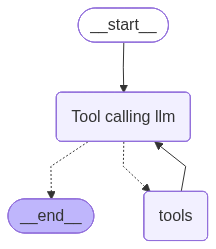

In [61]:
builder.compile()

In [62]:
query=builder.compile()

In [63]:
results=query.invoke({"messages":"what is the current news about ai"})

In [64]:
results

{'messages': [HumanMessage(content='what is the current news about ai', additional_kwargs={}, response_metadata={}, id='58bc3587-9598-4fdb-aa02-c8d78ea23822'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the current news about AI. Let me think about which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for scientific papers, so maybe not the best choice for current news. Wikipedia is good for general information but might not have the latest updates. The third option is tavily_search_results_json, which is described as a search engine optimized for current events. That sounds like the right fit here. \n\nI need to make sure the input is a search query. The user\'s query is "what is the current news about ai". I should structure the tool call with that query. Let me check the parameters again. The function requires a "query" parameter as a string. \n\nSo, the correct tool to use is 

In [65]:
for m in results['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the current news about ai
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (bgns7p8c0)
 Call ID: bgns7p8c0
  Args:
    query: current news about AI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News and AI Breakthroughs that Matter Most", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Summary: A new study from Microsoft Research, detailed in Fortune, identifies the specific career paths most \"exposed\" to the next wave of generative AI and autonomous agents. The research suggests that high-skill, white-collar roles, particularly those in finance, legal services, and software engineering, face the highest degree of task automation. Unlike previous industrial shifts that impacted manual labor, this AI wave

### Memory in langgraph

In [67]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [68]:
config={"configurable":{"thread_id":"1"}}

In [69]:
query=builder.compile(checkpointer=memory)

In [ ]:
results=query.invoke({"messages":"what is india GDP in last year"},config=config)